In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [79]:
df = pd.read_csv(r"C:\Users\Victus\Documents\Programming\machine learning\Electricity Consumption dataset\household_power_consumption.csv")
df.head(20)

,index,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,0,1/1/07,0:00:00,2.58,0.136,241.97,10.6,0,0,0.0
1,1,1/1/07,0:01:00,2.552,0.1,241.75,10.4,0,0,0.0
2,2,1/1/07,0:02:00,2.55,0.1,241.64,10.4,0,0,0.0
3,3,1/1/07,0:03:00,2.55,0.1,241.71,10.4,0,0,0.0
4,4,1/1/07,0:04:00,2.554,0.1,241.98,10.4,0,0,0.0
5,5,1/1/07,0:05:00,2.55,0.1,241.83,10.4,0,0,0.0
6,6,1/1/07,0:06:00,2.534,0.096,241.07,10.4,0,0,0.0
7,7,1/1/07,0:07:00,2.484,0,241.29,10.2,0,0,0.0
8,8,1/1/07,0:08:00,2.468,0,241.23,10.2,0,0,0.0
9,9,1/1/07,0:09:00,2.486,0,242.18,10.2,0,0,0.0


In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260640 entries, 0 to 260639
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   index                  260640 non-null  int64  
 1   Date                   260640 non-null  str    
 2   Time                   260640 non-null  str    
 3   Global_active_power    260640 non-null  str    
 4   Global_reactive_power  260640 non-null  str    
 5   Voltage                260640 non-null  str    
 6   Global_intensity       260640 non-null  str    
 7   Sub_metering_1         260640 non-null  str    
 8   Sub_metering_2         260640 non-null  str    
 9   Sub_metering_3         256869 non-null  float64
dtypes: float64(1), int64(1), str(8)
memory usage: 19.9 MB


In [81]:
df.isnull().sum()

index                       0
Date                        0
Time                        0
Global_active_power         0
Global_reactive_power       0
Voltage                     0
Global_intensity            0
Sub_metering_1              0
Sub_metering_2              0
Sub_metering_3           3771
dtype: int64

In [82]:
(df["Sub_metering_3"].isnull().sum() / len(df)) * 100

np.float64(1.4468232044198897)

In [83]:
df = df.dropna()
df.isnull().sum()

index                    0
Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [84]:
df.shape

(256869, 10)

In [85]:
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    dayfirst=True
)

C:\Users\Victus\AppData\Local\Temp\ipykernel_28104\239766308.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DateTime"] = pd.to_datetime(


In [86]:
df["Month"] = df["DateTime"].dt.month
df["Hour"] = df["DateTime"].dt.hour
df["DayOfWeek"] = df["DateTime"].dt.dayofweek   # Monday=0, Sunday=6
df["Week"] = df["DateTime"].dt.isocalendar().week
df["weekend"] = df["DayOfWeek"].isin([5,6]).astype(int)

In [87]:
df.drop(columns=["Date", "Time", "DateTime"], inplace=True)

In [88]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [89]:
print(df.dtypes)

index                      int64
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1             int64
Sub_metering_2             int64
Sub_metering_3           float64
Month                      int32
Hour                       int32
DayOfWeek                  int32
Week                      UInt32
weekend                    int64
dtype: object


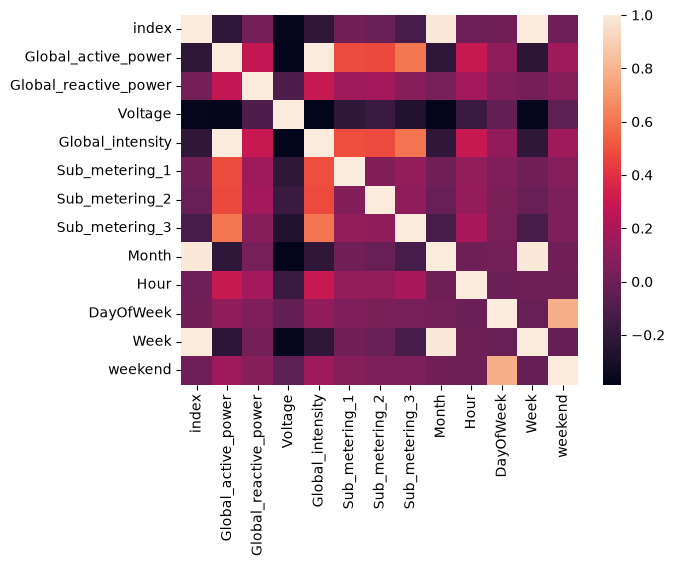

In [90]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

In [ ]:
x = df.drop(columns=["Global_active_power"])
y = df["Global_active_power"]

In [92]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [93]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [94]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [95]:
print("MSE: ", mean_squared_error(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("R2 Score: ", r2_score(y_test, y_pred))

MSE:  0.002085788271409376
MAE:  0.02879531012699649
R2 Score:  0.9984917881890938


## KNN Regressor

In [96]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [97]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [99]:
model = KNeighborsRegressor(n_neighbors=8)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [100]:
print("MSE: ", mean_squared_error(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("R2 Score: ", r2_score(y_test, y_pred))

MSE:  0.008199804526608791
MAE:  0.03855831743683575
R2 Score:  0.994070806608862


## Random Forest Regressor

In [101]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [102]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [103]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [104]:
model = RandomForestRegressor(n_estimators=100, max_depth=10,random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [105]:
print("MSE: ", mean_squared_error(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("R2 Score: ", r2_score(y_test, y_pred))

MSE:  0.0012565826877453587
MAE:  0.019956306633803066
R2 Score:  0.9990913781245125
